In [1]:
import sys
import os
cwd = os.getcwd()
functions_path = os.path.join(os.path.dirname(cwd), 'functions')
if functions_path not in sys.path:
    sys.path.append(functions_path)
import site
# Add user site-packages path manually
site_user_base = site.getusersitepackages()
if site_user_base not in sys.path:
    sys.path.append(site_user_base)

In [2]:
%matplotlib inline

In [3]:
#%load_ext memory_profiler

In [4]:
import warnings
import time
import numpy as np
import seaborn as sns
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy
from importlib import reload
import utils
import FCD_jax
import mpr_jax
mpr_jax=reload(mpr_jax)
FCD_jax=reload(FCD_jax)

warnings.simplefilter("ignore")

# Define a timer and a wrapper and the plot function
#### The wrapper should take as input G and the other latent variables 'params' and give as output the raw signal (r=firing rates, v=membrane potetials, bold_d=BOLD signal)

In [5]:
#jax.config.update("jax_enable_x64", True)

In [6]:
def timer(func):
    def wrapper(*args, **kwargs):
        import time
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.2f} seconds")
        return result
    return wrapper

In [7]:
@timer
def wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [8]:
@timer
def alternative_wrapper(g, par, close=True):
    par = deepcopy(par)
    par["G"] = g
    # Create JAX simulation object
    sde = mpr_jax.MPR_sde.create(par)
    data = sde.run({})
    
    # Explicitly wait for the computation to finish before ending the timer
    data['rv_d'].block_until_ready()

    rv_t = data["rv_t"]
    rv_d = data["rv_d"]
    nn = par["weights"].shape[0]
    r = rv_d[:, :nn]
    v = rv_d[:, nn:]
    bold_d = data["bold_d"]
    bold_t = data["bold_t"]
    return rv_t, r, v, bold_t, bold_d

In [9]:
def plot(rv_t, r, v, bold_d, bold_t, g, close=True):
    step = 10
    fig, ax = plt.subplots(3, 1, figsize=(12, 6))
    ax[0].plot(rv_t[::step], r[::step, :], lw=0.1)
    ax[1].plot(rv_t[::step], v[::step, :], lw=0.1)
    ax[2].plot(bold_t, bold_d, lw=0.1)
    ax[0].set_ylabel("r")
    ax[1].set_ylabel("v")
    ax[2].set_ylabel("BOLD")
    # os.makedirs("data", exist_ok=True)
    # plt.savefig(f"data/control_vbi_{g:.3f}.png")
    # if close:
    #     plt.close()
    plt.show()

#### Toy simulation with n=6 brain regoins, for checking the JAX implementation

In [10]:
nn = 6
weights = nx.to_numpy_array(nx.complete_graph(nn))
params = {"G": 0.25, 
          "weights": weights,
          "t_end": 30000,
          "dt": 0.02,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 300.0, #it was 500
          "seed":42
          }

#### Warm up for benefitting of the JIT compilation

In [11]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 0.87 seconds


In [12]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 0.49 seconds


In [13]:
#jnp.isnan(r).sum()

In [14]:
#!free -h

In [15]:
#!cat /sys/fs/cgroup/memory.max

wrapper took 0.93 seconds


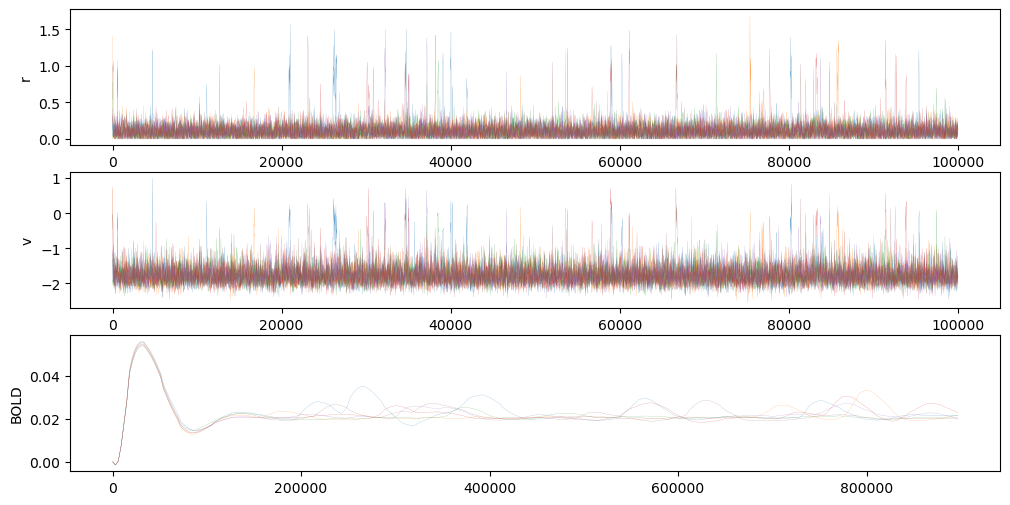

In [16]:
params['t_end'] = 100_000
g = 0.1
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

wrapper took 0.90 seconds


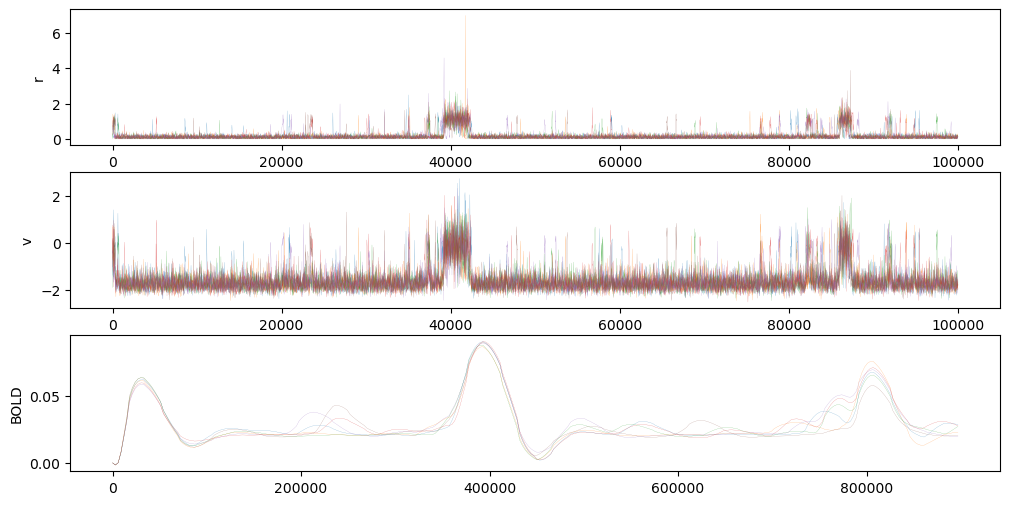

In [17]:
#params['t_end'] = 30000
g = 0.33
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

wrapper took 0.97 seconds


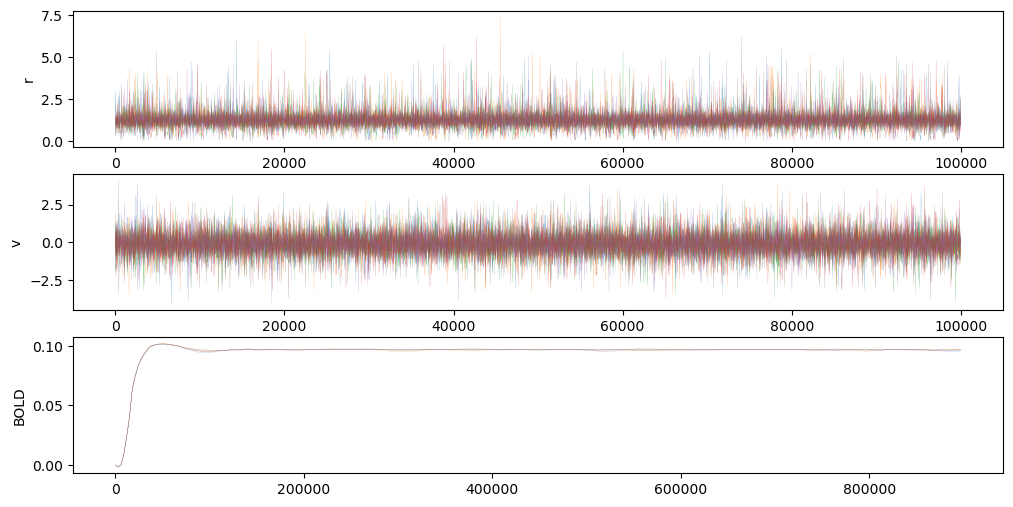

In [18]:
#params['t_end'] = 30000
g = 0.5
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

wrapper took 0.94 seconds


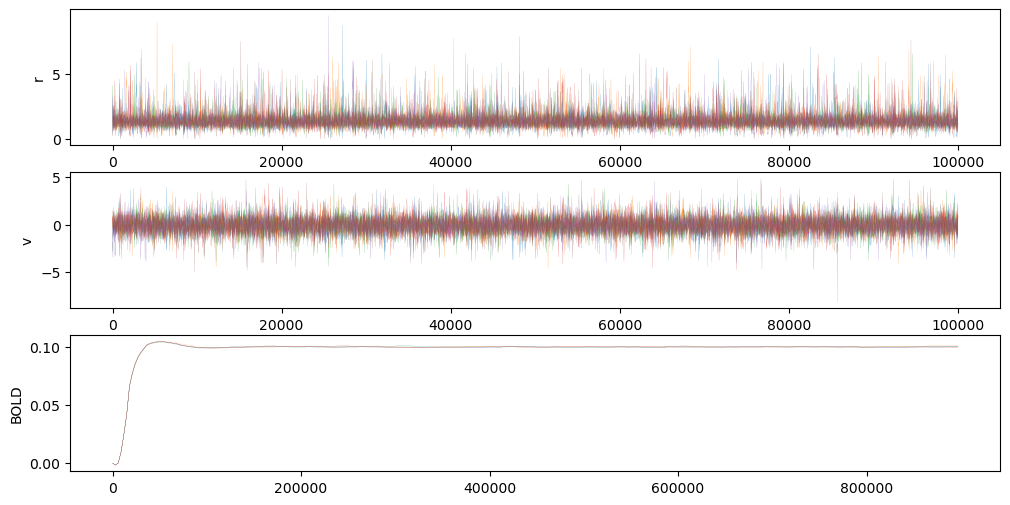

In [19]:
#params['t_end'] = 30000
g = 0.7
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

wrapper took 0.93 seconds


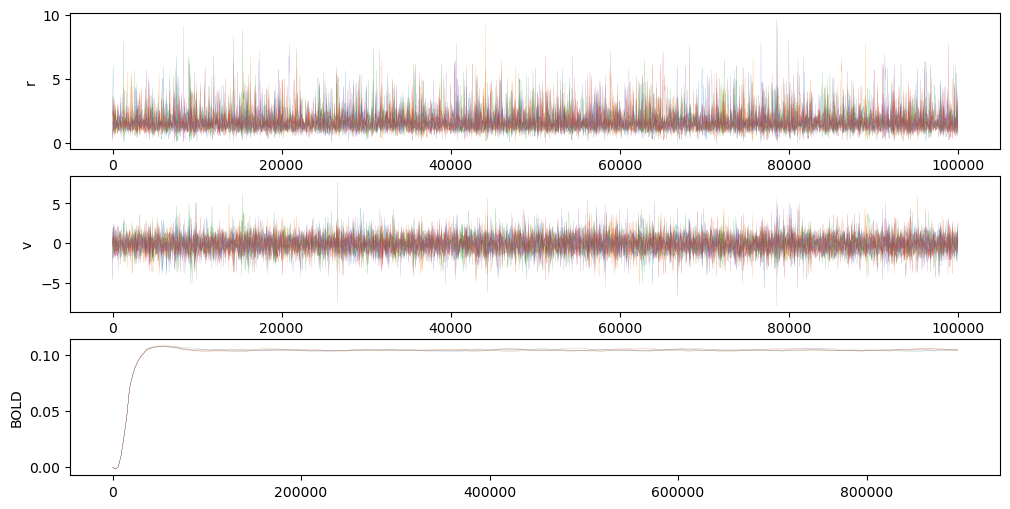

In [20]:
#params['t_end'] = 30000
g = 1.1
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
plot(rv_t, r, v, bold_d, bold_t, g)

### Upload structural connectivity (SC) matrix, normalize it and print it

In [21]:
datapath = utils.DATA_ROOT
weights = np.loadtxt(datapath+"/weights.txt", delimiter=None)

In [22]:
nn = len(weights)
params["weights"] = jnp.array(weights)/jnp.max(weights)

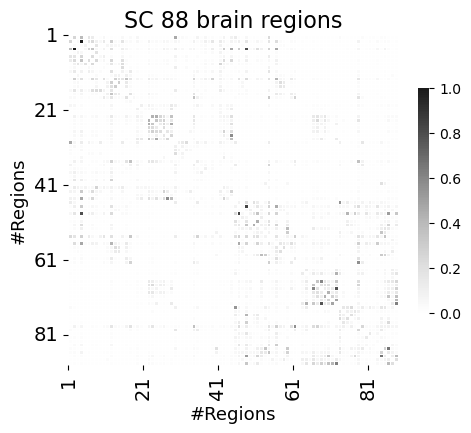

In [23]:
plt.figure(figsize=(5, 5))
mask = np.zeros_like(weights, dtype=bool)
mask[np.triu_indices_from(mask)] = False
#cmap = sns.diverging_palette(220, 10, as_cmap=True)
cmap='RdGy'
sns.heatmap(weights/np.max(weights), mask=mask, cmap=cmap, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('SC 88 brain regions',fontsize=16)
plt.ylabel('#Regions', fontsize=13.0)
plt.xlabel('#Regions', fontsize=13.0)
plt.xticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
plt.yticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
#plt.gca().invert_xaxis()
plt.tight_layout()
resultspath = utils.RESULTS_ROOT
#plt.savefig(os.path.join(resultspath,"SCmatrix.png"), dpi=800)
#plt.savefig(os.path.join(resultspath,"SCmatrix.eps"), dpi=800)
plt.show()

In [24]:
con = weights/np.max(weights)

In [25]:
con.shape, con.min(), con.max()

((88, 88), 0.0, 1.0)

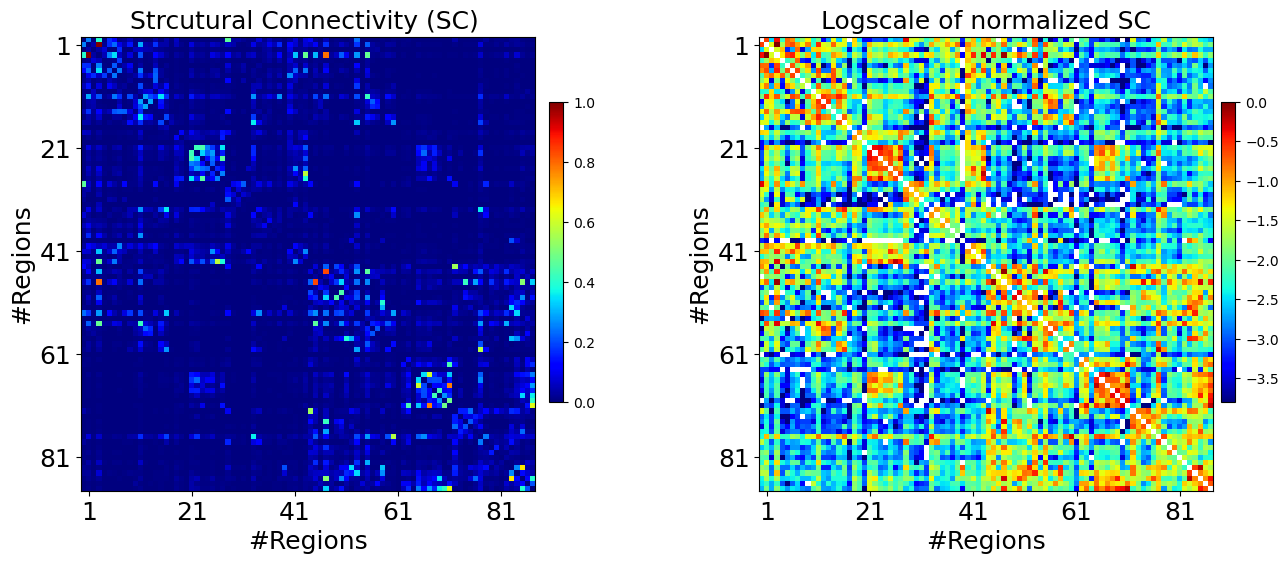

In [26]:
from matplotlib import colors, cm
import matplotlib.colors as mcolors

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
norm = colors.LogNorm(1e-7, con.max())
i=axs[0].imshow(con,cmap=cm.jet)
colorbar_ax = fig.add_axes([0.45, 0.3, 0.01, 0.5])
fig.colorbar(i, cax=colorbar_ax)
axs[0].set_title('Strcutural Connectivity (SC) ', fontsize=18.0)
axs[0].set_ylabel('#Regions', fontsize=18.0)
axs[0].set_xlabel('#Regions', fontsize=18.0)
axs[0].tick_params(labelsize=18)
axs[0].xaxis.set_ticks(np.r_[1:nn+1][::20])
axs[0].yaxis.set_ticks(np.r_[1:nn+1][::20])

i=axs[1].imshow(np.log10(con),cmap=cm.jet)
colorbar_ax = fig.add_axes([.93, 0.3, 0.01, 0.5])
fig.colorbar(i, cax=colorbar_ax)
axs[1].set_title('Logscale of normalized SC', fontsize=18.0)
axs[1].set_ylabel('#Regions', fontsize=18.0)
axs[1].set_xlabel('#Regions', fontsize=18.0)
axs[1].tick_params(labelsize=18)
axs[1].xaxis.set_ticks(np.r_[1:nn+1][::20])
axs[1].yaxis.set_ticks(np.r_[1:nn+1][::20])

fig.tight_layout(pad=2)

#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"SCmatrix_Normalized.png"), doi=800)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"SCmatrix_Normalized.eps"), doi=800)
plt.show()

In [27]:
con_positive=con.flatten()[con.flatten() != 0]
con_positive.shape[0]

7360

In [28]:
IC=con[np.r_[0:nn]][:,:].sum(axis=1)

In [29]:
print("The strongest connections received to each node from other nodes: \n", np.argsort(-IC)[0:5])

The strongest connections received to each node from other nodes: 
 [ 3 47 11 77 53]


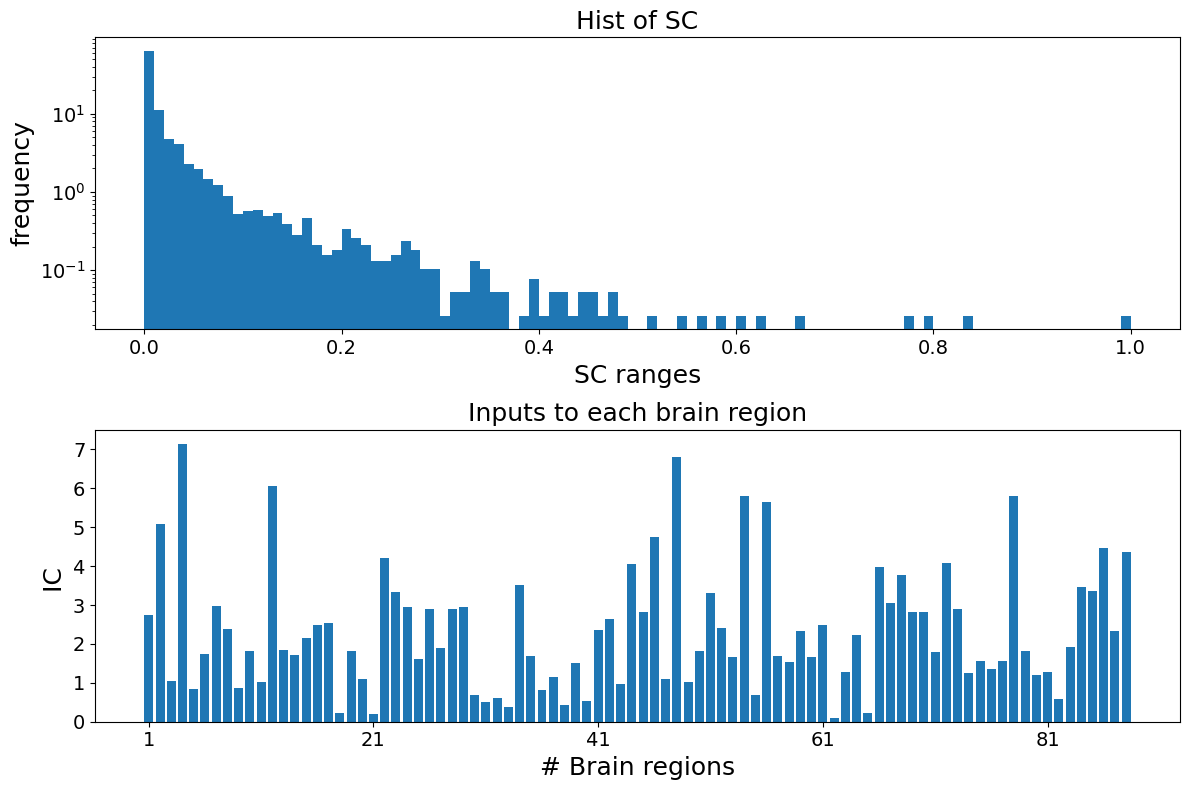

In [30]:
plt.figure(figsize=(12, 8))
plt.subplot(211)
plt.hist(con.flatten(), density=True, log=True, bins=100)
plt.title('Hist of SC', fontsize=18.0)
plt.ylabel('frequency', fontsize=18.0)
plt.xlabel('SC ranges', fontsize=18.0)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.subplot(212)
plt.bar(np.r_[0:nn], IC)

plt.title('Inputs to each brain region', fontsize=18.0)
plt.ylabel('IC ', fontsize=18.0)
plt.xlabel('# Brain regions', fontsize=18.0)
plt.xticks(np.r_[0:nn][::20], np.r_[1:nn+1][::20], fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"Hist_SC.png"), doi=800)
#plt.savefig(os.path.join(cwd+'/'+str(Res_dir),"Hist_SC.eps"), doi=800)
plt.show()

### Replicate figure S1 from the paper (adding FC of firing rates for comparison)

In [31]:
t_end = 300_000
params['t_end'] = t_end	

In [32]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 6.21 seconds


In [33]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 6.02 seconds


In [34]:
rv_t, r, v, bold_t, bold_d =  wrapper(0.33, params)

wrapper took 5.97 seconds


#### G=0, 0.5, 0.7: run simulation and save the output in variables

In [35]:
#%%memit
g = 0.0
rv_t, r, v, bold_t, bold_d = wrapper(g, params)

wrapper took 6.05 seconds


In [36]:
#%%memit
#plot(rv_t, r, v, bold_d, bold_t, g)
rv_t_G0 = rv_t
r_G0 = r
bold_t_G0 = bold_t
bold_G0 = bold_d

In [37]:
#%%memit
g = 0.5
rv_t, r, v, bold_t, bold_d = wrapper(g, params)

wrapper took 6.28 seconds


In [38]:
#%%memit
#plot(rv_t, r, v, bold_d, bold_t, g)
rv_t_G05 = rv_t
r_G05 = r
bold_t_G05 = bold_t
bold_G05 = bold_d

In [39]:
#%%memit
g = 0.7
rv_t, r, v, bold_t, bold_d = wrapper(g, params)
#plot(rv_t, r, v, bold_d, bold_t, g)

wrapper took 6.31 seconds


In [40]:
rv_t_G07 = rv_t
r_G07 = r
bold_t_G07 = bold_t
bold_G07 = bold_d 

In [41]:
#transpose for proper shape in the FCD calculation
bold_G0_T = bold_G0.T     # shape: (88, 300000)
bold_G05_T = bold_G05.T
bold_G07_T = bold_G07.T

### Calculate the corrcoef of firing rates 

In [42]:
FC_r_G0 = np.corrcoef(r_G0.T)

In [43]:
FC_r_G05 = np.corrcoef(r_G05.T)

In [44]:
FC_r_G07 = np.corrcoef(r_G07.T)

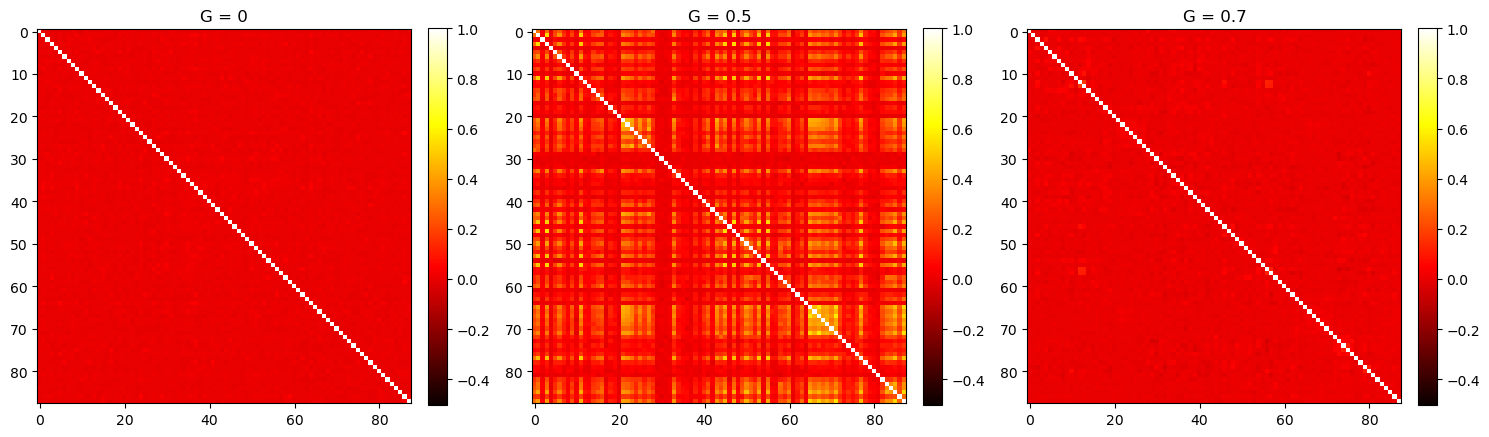

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# List of matrices and titles
matrices = [FC_r_G0, FC_r_G05, FC_r_G07]
titles = ["G = 0", "G = 0.5", "G = 0.7"]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, vmin=-0.5, vmax=1, cmap='hot')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Calculate FC and FCD of the BOLD signal to replicate figure S1

In [46]:
wwidth = 30  # must be < 60
maxNwindows = 200
olap = 0.94
cut = 50

FCD_G0, FCvec_G0, _ = FCD_jax.extract_FCD(bold_G0.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
FCD_G05, FCvec_G05, _ = FCD_jax.extract_FCD(bold_G05.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)
FCD_G07, FCvec_G07, _ = FCD_jax.extract_FCD(bold_G07.T, wwidth=wwidth, maxNwindows=maxNwindows, olap=olap)

FC_G0 = FCD_jax.get_fc(bold_G0[cut:].T)
FC_G05 = FCD_jax.get_fc(bold_G05[cut:].T)
FC_G07 = FCD_jax.get_fc(bold_G07[cut:].T)

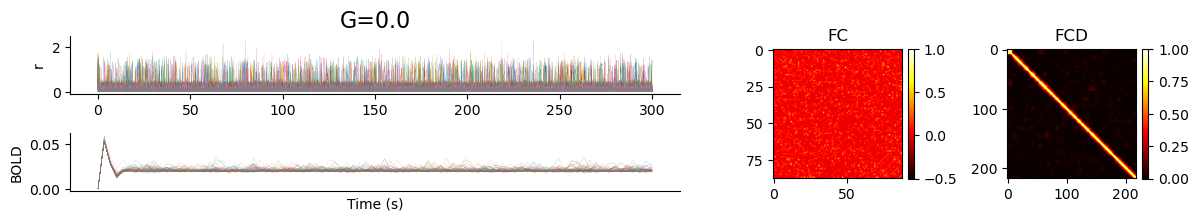

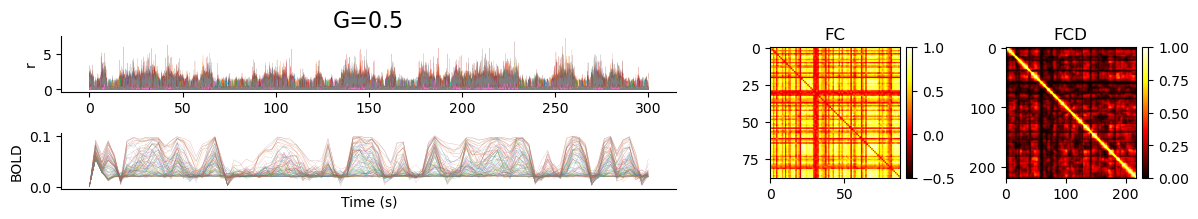

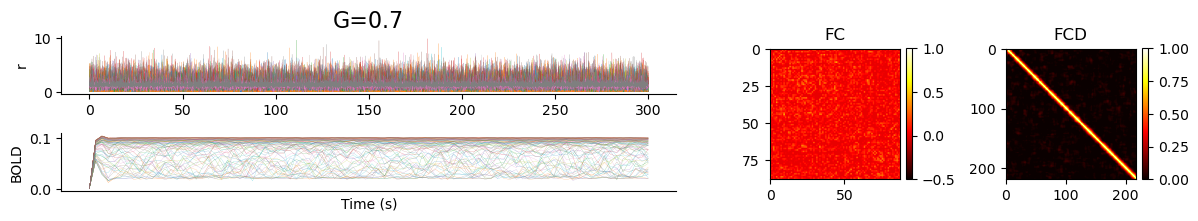

In [47]:
def plot_fc_fcd(rv_t, r, bold_t, bold_d, FC, FCD, label='G=?'):
    step = 10
    fig = plt.figure(figsize=(12, 6))  # Wide and not too tall

    # r plot (top-left, shorter height)
    ax1 = plt.subplot2grid((6, 5), (0, 0), colspan=3, rowspan=1)
    ax1.plot(rv_t[::step]/1000, r[::step, :], lw=0.1)
    ax1.set_ylabel("r")

    ax1.set_title(f"{label}", fontsize=16)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # BOLD plot (middle-left, shorter height)
    ax2 = plt.subplot2grid((6, 5), (1, 0), colspan=3, rowspan=1)
    ax2.plot(bold_t[::step]/1000, bold_d[::step], lw=0.1)
    ax2.set_ylabel("BOLD")
    ax2.set_xlabel("Time (s)")
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xticks([])

    # FC plot (full right height, top half)
    ax3 = plt.subplot2grid((6, 5), (0, 3), rowspan=2, colspan=1)
    im1 = ax3.imshow(FC, vmin=-0.5, vmax=1, cmap='hot')
    ax3.set_title("FC")
    plt.colorbar(im1, ax=ax3, fraction=0.046, pad=0.04)

    # FCD plot (full right height, bottom half)
    ax4 = plt.subplot2grid((6, 5), (0, 4), rowspan=2, colspan=1)
    im2 = ax4.imshow(FCD, vmin=0, vmax=1, cmap='hot')
    ax4.set_title("FCD")
    plt.colorbar(im2, ax=ax4, fraction=0.046, pad=0.04)

    plt.tight_layout()
    name = f'/home/monica/Desktop/GSoC/repos/GSoC_T3.3_inference/results/figureS1.png'
    plt.savefig(name,dpi=300)
    plt.show()



plot_fc_fcd(rv_t_G0, r_G0, bold_t_G0, bold_G0, FC_G0, FCD_G0, label='G=0.0')
plot_fc_fcd(rv_t_G05, r_G05, bold_t_G05, bold_G05, FC_G05, FCD_G05, label='G=0.5')
plot_fc_fcd(rv_t_G07, r_G07, bold_t_G07, bold_G07, FC_G07, FCD_G07, label='G=0.7')


In [48]:
len(bold_t_G0)

900

In [49]:
# Suppose fcd_matrix is your output from extract_FCD
triu_idx = jnp.triu_indices(FCD_G0.shape[0], k=1)  # k=1 excludes the diagonal
upper_vals = FCD_G0[triu_idx]  # Extract upper triangular entries
var_upper = jnp.var(upper_vals)    # Compute variance
var_upper

Array(0.01629473, dtype=float32)

In [50]:
# Suppose fcd_matrix is your output from extract_FCD
triu_idx = jnp.triu_indices(FCD_G05.shape[0], k=1)  # k=1 excludes the diagonal
upper_vals = FCD_G05[triu_idx]  # Extract upper triangular entries
var_upper = jnp.var(upper_vals)    # Compute variance
var_upper

Array(0.02130528, dtype=float32)

In [51]:
# Suppose fcd_matrix is your output from extract_FCD
triu_idx = jnp.triu_indices(FCD_G07.shape[0], k=1)  # k=1 excludes the diagonal
upper_vals = FCD_G07[triu_idx]  # Extract upper triangular entries
var_upper = jnp.var(upper_vals)    # Compute variance
var_upper

Array(0.01600823, dtype=float32)

### Calculate FCD as a function of the fluidity

In [52]:
params_fluidity = {"G": 0.25, 
          "weights": weights/jnp.max(weights),
          "t_end": 100000,
          "dt": 0.01,
          "eta": jnp.array([-4.6]),
          "rv_decimate": 10,
          "noise_amp": 0.037,
          "tr": 300.0, #it was 500
          "seed":42
          }

In [53]:
@timer
def wrapper_fluidity(G, params, key):

    params["G"] = G
    sde = mpr_jax.MPR_sde.create(params)
    data = sde.run({})
    bold_d = data["bold_d"].T
    nnodes, T = bold_d.shape

    shift, starts = FCD_jax.precompute_shift_and_starts(T, wwidth=30, olap=0.94)
    FCD_full = FCD_jax.extract_FCD_jax_jitted(bold_d, starts, nnodes, wwidth=30, olap=0.94) 
    
    fluidity = FCD_jax.fluidity(FCD_full)
    
    return fluidity

In [54]:
g_values = np.arange(0., 1.5, 0.05)
fluidity_dict = {'fluidity':[]}
for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    res = wrapper_fluidity(g, params_fluidity, key)
    fluidity_dict['fluidity'].append(float(res))

wrapper_fluidity took 5.17 seconds
wrapper_fluidity took 4.01 seconds
wrapper_fluidity took 4.06 seconds
wrapper_fluidity took 4.06 seconds
wrapper_fluidity took 4.14 seconds
wrapper_fluidity took 4.04 seconds
wrapper_fluidity took 3.99 seconds
wrapper_fluidity took 3.96 seconds
wrapper_fluidity took 4.11 seconds
wrapper_fluidity took 4.07 seconds
wrapper_fluidity took 4.16 seconds
wrapper_fluidity took 4.01 seconds
wrapper_fluidity took 4.29 seconds
wrapper_fluidity took 4.16 seconds
wrapper_fluidity took 3.86 seconds
wrapper_fluidity took 4.12 seconds
wrapper_fluidity took 3.96 seconds
wrapper_fluidity took 4.04 seconds
wrapper_fluidity took 4.00 seconds
wrapper_fluidity took 4.01 seconds
wrapper_fluidity took 4.02 seconds
wrapper_fluidity took 4.05 seconds
wrapper_fluidity took 4.18 seconds
wrapper_fluidity took 4.13 seconds
wrapper_fluidity took 4.04 seconds
wrapper_fluidity took 4.04 seconds
wrapper_fluidity took 4.23 seconds
wrapper_fluidity took 4.18 seconds
wrapper_fluidity too

In [55]:
for key in fluidity_dict.keys() :
    fluidity_dict[key] = np.array(fluidity_dict[key])

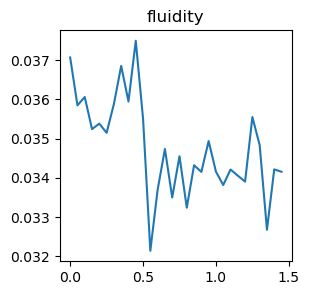

In [56]:
fig, ax = plt.subplots(ncols=len(fluidity_dict), figsize=(3, 3))

# if there's only one Axes, wrap it in a list
if len(fluidity_dict) == 1:
    ax = [ax]

for i, (k, v) in enumerate(fluidity_dict.items()):
    ax[i].plot(g_values, v)
    ax[i].set(title=k)

In [57]:
g_values = np.arange(0.4, 0.6, 0.005)
fluidity_dict = {'fluidity':[]}
for g in g_values :
    key = jax.random.PRNGKey(int(time.time()))
    res = wrapper_fluidity(g, params_fluidity, key)
    fluidity_dict['fluidity'].append(float(res))

wrapper_fluidity took 4.07 seconds
wrapper_fluidity took 4.21 seconds
wrapper_fluidity took 4.25 seconds
wrapper_fluidity took 4.12 seconds
wrapper_fluidity took 4.06 seconds
wrapper_fluidity took 4.14 seconds
wrapper_fluidity took 4.53 seconds
wrapper_fluidity took 4.16 seconds
wrapper_fluidity took 4.24 seconds
wrapper_fluidity took 4.23 seconds
wrapper_fluidity took 4.36 seconds
wrapper_fluidity took 4.47 seconds
wrapper_fluidity took 4.33 seconds
wrapper_fluidity took 4.50 seconds
wrapper_fluidity took 4.12 seconds
wrapper_fluidity took 4.18 seconds
wrapper_fluidity took 4.19 seconds
wrapper_fluidity took 4.16 seconds
wrapper_fluidity took 4.05 seconds
wrapper_fluidity took 4.04 seconds
wrapper_fluidity took 4.15 seconds
wrapper_fluidity took 4.13 seconds
wrapper_fluidity took 3.90 seconds
wrapper_fluidity took 4.04 seconds
wrapper_fluidity took 4.23 seconds
wrapper_fluidity took 4.45 seconds
wrapper_fluidity took 4.21 seconds
wrapper_fluidity took 4.45 seconds
wrapper_fluidity too

In [217]:
for key in fluidity_dict.keys() :
    fluidity_dict[key] = np.array(fluidity_dict[key])

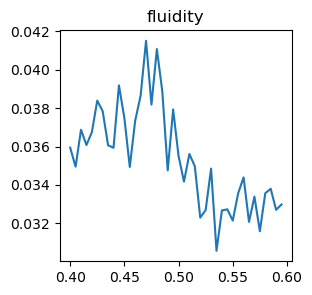

In [218]:
fig, ax = plt.subplots(ncols=len(fluidity_dict), figsize=(3, 3))

# if there's only one Axes, wrap it in a list
if len(fluidity_dict) == 1:
    ax = [ax]

for i, (k, v) in enumerate(fluidity_dict.items()):
    ax[i].plot(g_values, v)
    ax[i].set(title=k)

In [219]:
import mpr_jax_pymc
mpr_jax_pymc=reload(mpr_jax_pymc)

In [220]:
G = params['G']
weights = params['weights']

t_end = params['t_end']
cut = 30

In [221]:
x=mpr_jax_pymc.wrapper_fc(0.737,weights,t_end,cut)

wrapper_fc took 15.03 seconds


In [222]:
G_test_values = np.linspace(0.6, 1.0, 40, dtype=np.float32)
for ggg in G_test_values:
    x=mpr_jax_pymc.wrapper_fc(ggg,weights,t_end,cut)
    print('G = ', ggg, 'wrapper = ',np.isnan(x).any())

wrapper_fc took 14.70 seconds
G =  0.6 wrapper =  False
wrapper_fc took 14.72 seconds
G =  0.61025643 wrapper =  False
wrapper_fc took 15.43 seconds
G =  0.62051284 wrapper =  False
wrapper_fc took 16.22 seconds
G =  0.63076925 wrapper =  False
wrapper_fc took 19.46 seconds
G =  0.64102566 wrapper =  False
wrapper_fc took 17.04 seconds
G =  0.6512821 wrapper =  False
wrapper_fc took 19.38 seconds
G =  0.6615385 wrapper =  False
wrapper_fc took 16.07 seconds
G =  0.6717949 wrapper =  False
wrapper_fc took 15.28 seconds
G =  0.6820513 wrapper =  False
wrapper_fc took 15.12 seconds
G =  0.6923077 wrapper =  False
wrapper_fc took 14.95 seconds
G =  0.7025641 wrapper =  False
wrapper_fc took 14.85 seconds
G =  0.71282053 wrapper =  False
wrapper_fc took 16.44 seconds
G =  0.72307694 wrapper =  False
wrapper_fc took 17.92 seconds
G =  0.73333335 wrapper =  False
wrapper_fc took 15.42 seconds
G =  0.74358976 wrapper =  False
wrapper_fc took 15.64 seconds
G =  0.75384617 wrapper =  False
wrapp

In [223]:
SC

NameError: name 'SC' is not defined

In [224]:
np.shape(x)

(3828,)

In [225]:
import pytensor.tensor as pt
import numpy as np

G_sym   = pt.fscalar("G")
SC_sym  = pt.fmatrix("SC")
t_sym   = pt.fscalar("t_end")
cut_sym = pt.fscalar("cut")

FC_sym = mpr_jax_pymc.pytensor_forward_model_matrix(G_sym, SC_sym, t_sym, cut_sym)


In [226]:
import pytensor

FC_fn = pytensor.function(
    inputs=[G_sym, SC_sym, t_sym, cut_sym],
    outputs=FC_sym,
)


In [227]:
G_test_values = np.linspace(0.0, 1.0, 20, dtype=np.float32)

for g in G_test_values:
    try:
        val = FC_fn(
            np.float32(g),
            np.array(SC, dtype=np.float32),
            np.float32(t_end),
            np.float32(cut),
        )
        print(f"G={g:.3f}: OK | shape={val.shape} | any NaN? {np.isnan(val).any()}")
    except Exception as e:
        print(f"G={g:.3f}: ERROR -> {e}")


G=0.000: ERROR -> name 'SC' is not defined
G=0.053: ERROR -> name 'SC' is not defined
G=0.105: ERROR -> name 'SC' is not defined
G=0.158: ERROR -> name 'SC' is not defined
G=0.211: ERROR -> name 'SC' is not defined
G=0.263: ERROR -> name 'SC' is not defined
G=0.316: ERROR -> name 'SC' is not defined
G=0.368: ERROR -> name 'SC' is not defined
G=0.421: ERROR -> name 'SC' is not defined
G=0.474: ERROR -> name 'SC' is not defined
G=0.526: ERROR -> name 'SC' is not defined
G=0.579: ERROR -> name 'SC' is not defined
G=0.632: ERROR -> name 'SC' is not defined
G=0.684: ERROR -> name 'SC' is not defined
G=0.737: ERROR -> name 'SC' is not defined
G=0.789: ERROR -> name 'SC' is not defined
G=0.842: ERROR -> name 'SC' is not defined
G=0.895: ERROR -> name 'SC' is not defined
G=0.947: ERROR -> name 'SC' is not defined
G=1.000: ERROR -> name 'SC' is not defined


In [228]:
# ---- Diagnostic: is the slowdown thermal or memory? ----
import time, gc, glob
import jax
import matplotlib.pyplot as plt

# Point `p` at your nn=88 params dict, and force the long config:
p = dict(params)              # <-- your 88-node params
p["t_end"] = 300000
G = 0.5

def cpu_mhz():
    # current core clock; falls back gracefully
    try:
        f = glob.glob("/sys/devices/system/cpu/cpu*/cpufreq/scaling_cur_freq")
        vals = [int(open(x).read()) / 1000 for x in f]   # kHz -> MHz
        return max(vals) if vals else float("nan")
    except Exception:
        try:
            lines = [l for l in open("/proc/cpuinfo") if "MHz" in l]
            return max(float(l.split(":")[1]) for l in lines)
        except Exception:
            return float("nan")

def timed_run(record_rv=True, fast_bold=False):
    sde = mpr_jax.MPR_sde.create(p)
    t0 = time.time()
    d = sde.run({"G": G}, record_rv=record_rv, fast_bold=fast_bold)
    jax.block_until_ready(d)
    return time.time() - t0, d

# Warm up BOTH configs so no timed run pays compile cost
print("compiling (not timed)...")
timed_run(record_rv=True,  fast_bold=False)
timed_run(record_rv=False, fast_bold=True)

print(f"\nstart CPU clock: {cpu_mhz():.0f} MHz")
print(f"{'run':<26}{'time(s)':>9}{'CPU MHz':>10}")

# A) 4 identical back-to-back runs -- does time drift up?
for i in range(4):
    t, d = timed_run(record_rv=True, fast_bold=False)
    print(f"{'back-to-back #'+str(i+1):<26}{t:9.2f}{cpu_mhz():10.0f}")
    del d

# B) cool down 60 s, free memory, then run again
print("\ncooling down 60 s (freeing figures + memory)...")
plt.close("all"); gc.collect(); time.sleep(60)
t, d = timed_run(record_rv=True, fast_bold=False); del d
print(f"{'after 60s cooldown':<26}{t:9.2f}{cpu_mhz():10.0f}")

# C) record_rv=False (+fast_bold): removes the ~2 GB RV buffer
print()
for i in range(3):
    t, d = timed_run(record_rv=False, fast_bold=True)
    print(f"{'rv=False,fast #'+str(i+1):<26}{t:9.2f}{cpu_mhz():10.0f}")
    del d; gc.collect()

print("""
Interpretation:
  - Back-to-back times climb AND CPU MHz drops         -> THERMAL throttling
  - Cooldown run returns toward the fast (~12 s) time   -> THERMAL
  - Times stay high but rv=False runs are much faster/steadier -> MEMORY (the 2 GB RV buffer)
  - Both effects can be present at once.
""")


compiling (not timed)...

start CPU clock: 2854 MHz
run                         time(s)   CPU MHz
back-to-back #1               15.21      3100
back-to-back #2               15.36      3168
back-to-back #3               15.26      3100
back-to-back #4               15.28      3209

cooling down 60 s (freeing figures + memory)...
after 60s cooldown            12.00      4286

rv=False,fast #1               9.20      2793
rv=False,fast #2              11.81      2800
rv=False,fast #3              11.22      3000

Interpretation:
  - Back-to-back times climb AND CPU MHz drops         -> THERMAL throttling
  - Cooldown run returns toward the fast (~12 s) time   -> THERMAL
  - Times stay high but rv=False runs are much faster/steadier -> MEMORY (the 2 GB RV buffer)
  - Both effects can be present at once.



In [49]:
# ============ Testing the new mpr_jax flags in SIMULATION only ============
# New knobs on mpr_jax.run():
#   clip_mode : "hard" (default, jnp.clip) | "soft" (tanh saturation) | "none"
#   fast_bold : integrate BOLD once per rv_decimate block (approx, ~1.4x faster)
#   grad_horizon : truncated-BPTT window (int). ONLY affects gradients, not the
#                  forward simulation (forward is bit-exact for any grad_horizon).
# Reload so the edited modules are active:
import importlib, time
import numpy as np, jax, jax.numpy as jnp
mpr_jax = importlib.reload(mpr_jax)
import FCD_jax; FCD_jax = importlib.reload(FCD_jax)

p = dict(params)          # point at your own params if you like
p["t_end"] = 5000
G = 0.5
nn = p["weights"].shape[0]

def simulate(clip_mode="hard", fast_bold=False):
    sde = mpr_jax.MPR_sde.create({**p, "clip_mode": clip_mode})
    t0 = time.time()
    d = sde.run({"G": G}, record_rv=False, fast_bold=fast_bold)
    jax.block_until_ready(d)
    return d, time.time() - t0

# --- (A) forward effect of clip_mode and fast_bold (FC should barely change) ---
dh, th = simulate("hard", False)
ds, _  = simulate("soft", False)
df, tf = simulate("hard", True)
FCh = FCD_jax.get_fc(dh["bold_d"][2:].T)
FCs = FCD_jax.get_fc(ds["bold_d"][2:].T)
FCf = FCD_jax.get_fc(df["bold_d"][2:].T)
print("clip_mode  soft vs hard : max|FC diff| =", float(jnp.abs(FCh - FCs).max()))
print("fast_bold  on   vs off  : max|FC diff| =", float(jnp.abs(FCh - FCf).max()),
      f"  (time hard/off={th:.2f}s  hard/fast={tf:.2f}s)")

# --- (B) grad_horizon: gradient of mean firing rate <r> wrt G (record_rv=True) ---
# Compare autodiff (full + truncated) against a finite-difference "truth".
def mean_r(Gval, clip_mode, gh):
    sde = mpr_jax.MPR_sde.create({**p, "clip_mode": clip_mode})
    d = sde.run({"G": Gval}, record_rv=True, grad_horizon=gh)
    return jnp.mean(d["rv_d"][:, :nn])

h = 0.02
print("\nd<r>/dG :  FD(truth)   vs   autodiff full(hard)   vs   autodiff trunc200(soft)")
for Gval in [0.3, 0.6, 0.9]:
    fd     = float((mean_r(Gval + h, "soft", 0) - mean_r(Gval - h, "soft", 0)) / (2 * h))
    g_full = float(jax.grad(lambda x: mean_r(x, "hard", 0))(jnp.float32(Gval)))
    g_tr   = float(jax.grad(lambda x: mean_r(x, "soft", 200))(jnp.float32(Gval)))
    print(f"  G={Gval}:  FD={fd:+.3f}    full={g_full:+.2e}    trunc={g_tr:+.3f}")

print("""
Read-out:
  (A) soft clip and fast_bold change FC only slightly (~1e-3) -> safe speed/stability knobs.
  (B) autodiff 'full' explodes in the chaotic regime; 'trunc' is bounded and tracks FD
      for the LOCAL observable <r>. For FC/FCD the truncated gradient collapses to ~0
      (long-horizon dependence) -> use finite differences there.
""")


clip_mode  soft vs hard : max|FC diff| = 0.013430655002593994
fast_bold  on   vs off  : max|FC diff| = 9.274482727050781e-05   (time hard/off=0.58s  hard/fast=0.41s)

d<r>/dG :  FD(truth)   vs   autodiff full(hard)   vs   autodiff trunc200(soft)
  G=0.3:  FD=+0.090    full=-6.51e+01    trunc=+0.014
  G=0.6:  FD=+1.947    full=+nan    trunc=+0.393
  G=0.9:  FD=+0.737    full=+nan    trunc=+0.421

Read-out:
  (A) soft clip and fast_bold change FC only slightly (~1e-3) -> safe speed/stability knobs.
  (B) autodiff 'full' explodes in the chaotic regime; 'trunc' is bounded and tracks FD
      for the LOCAL observable <r>. For FC/FCD the truncated gradient collapses to ~0
      (long-horizon dependence) -> use finite differences there.

